# 03 - Ajuste espectral wavelet/hibrido

Este notebook verifica el ajuste espectral contra el objetivo `EPU_475` y contra una salida SeismoMatch disponible en el repositorio. El metodo recomendado para produccion es `hybrid`: usa una actualizacion estable en frecuencia y una correccion wavelet localizada que solo se acepta cuando reduce el error espectral.

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd().resolve()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / 'src'))

import matplotlib.pyplot as plt
import pandas as pd

from signalprocessor.io import read_motion, read_target_spectrum
from signalprocessor.matching import MatchingConfig, match_spectrum
from signalprocessor.scaling import linear_scale, spectral_misfit
from signalprocessor.spectra import response_spectrum

In [2]:
seed = read_motion(ROOT / 'examples/data/benchmark/unscaled_motion/ATICOEW.csv')
seismomatch = read_motion(ROOT / 'examples/data/benchmark/scaled_motion/ATICOEW.txt')
target = read_target_spectrum(ROOT / 'examples/data/response_spectrum/EPU_475.csv')

T_MIN = 0.2
T_MAX = 2.0

linear = linear_scale(seed, target, t_min=T_MIN, t_max=T_MAX)
matched = match_spectrum(
    seed,
    target,
    MatchingConfig(
        method='hybrid',
        max_iterations=15,
        relaxation=0.35,
        t_min=T_MIN,
        t_max=T_MAX,
    ),
)
seismomatch_spec = response_spectrum(seismomatch, target.periods, output_units=target.units, damping=target.damping)

pd.DataFrame([
    {'serie': 'lineal', **spectral_misfit(linear.scaled_spectrum, target, t_min=T_MIN, t_max=T_MAX)},
    {'serie': 'SignalProcessor hybrid', **spectral_misfit(matched.spectrum, target, t_min=T_MIN, t_max=T_MAX)},
    {'serie': 'SeismoMatch referencia', **spectral_misfit(seismomatch_spec, target, t_min=T_MIN, t_max=T_MAX)},
])

,serie,max_abs_error,rms_log_error,mean_ratio
0,lineal,1.498769,0.517697,1.000000
1,SignalProcessor hybrid,0.042995,0.017871,0.999816
2,SeismoMatch referencia,0.051662,0.020645,0.990136


In [3]:
pd.DataFrame(matched.history)

,iteration,max_abs_log_error,rms_log_error
0,0.0,0.915798,0.517697
1,1.0,0.689239,0.383349
2,2.0,0.551089,0.281058
3,3.0,0.412457,0.202466
4,4.0,0.311730,0.148248
5,5.0,0.238898,0.110159
6,6.0,0.185090,0.082813
7,7.0,0.145840,0.062826
8,8.0,0.115547,0.046740
9,9.0,0.092750,0.036659


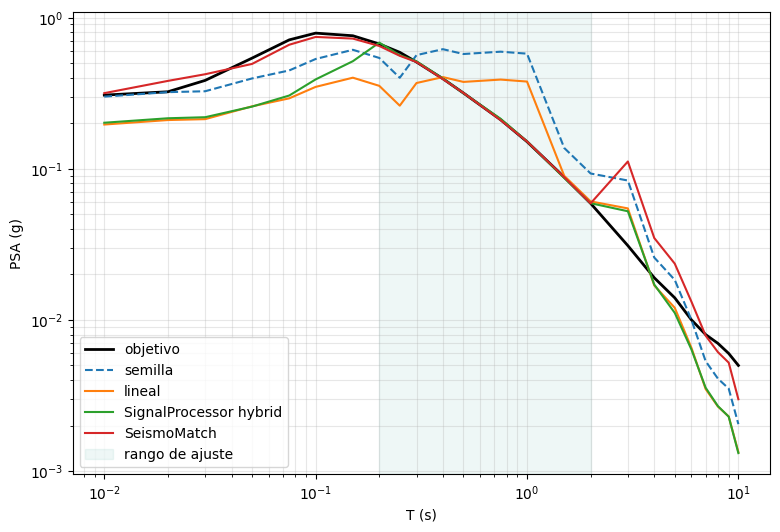

In [4]:
seed_spec = response_spectrum(seed, target.periods)

plt.figure(figsize=(9, 6))
plt.loglog(target.periods, target.sa, 'k-', lw=2.0, label='objetivo')
plt.loglog(seed_spec.periods, seed_spec.sa, '--', label='semilla')
plt.loglog(linear.scaled_spectrum.periods, linear.scaled_spectrum.sa, label='lineal')
plt.loglog(matched.spectrum.periods, matched.spectrum.sa, label='SignalProcessor hybrid')
plt.loglog(seismomatch_spec.periods, seismomatch_spec.sa, label='SeismoMatch')
plt.axvspan(T_MIN, T_MAX, color='#2a9d8f', alpha=0.08, label='rango de ajuste')
plt.xlabel('T (s)')
plt.ylabel('PSA (g)')
plt.grid(True, which='both', alpha=0.3)
plt.legend()

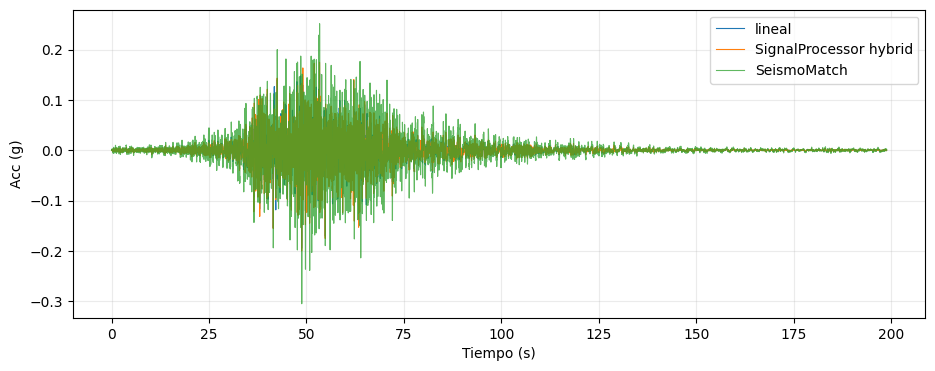

In [5]:
plt.figure(figsize=(11, 4))
plt.plot(linear.record.time, linear.record.as_units('g').acceleration, lw=0.8, label='lineal')
plt.plot(matched.record.time, matched.record.as_units('g').acceleration, lw=0.8, label='SignalProcessor hybrid')
plt.plot(seismomatch.time, seismomatch.as_units('g').acceleration, lw=0.8, alpha=0.75, label='SeismoMatch')
plt.xlabel('Tiempo (s)')
plt.ylabel('Acc (g)')
plt.grid(alpha=0.25)
plt.legend()